# Minimal-Cost Password-Leak Attacks

This notebook uses Python APIs (no CLI wrappers) of `proverifbatch` to:

- generate and verify scenarios, computing **minimal-cost combinations** that break queries,
- render attack trees for the scenarios that break `no pw leakage`.

In [13]:
import sys

from pathlib import Path
import pandas as pd
from IPython.display import Markdown, SVG, display

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

for module_name in list(sys.modules):
    if module_name == "proverifbatch" or module_name.startswith("proverifbatch."):
        del sys.modules[module_name]

EXAMPLES = [
    PROJECT_ROOT / "examples" / "hashed_passwords_paper.pv",
    PROJECT_ROOT / "examples" / "singularized_passwords_paper.pv",
]

TARGET_QUERY_TAG = "no pw leakage"


In [14]:
# Generate scenarios + run ProVerif via API

from proverifbatch.scenarios import ScenarioPreprocessor

# Generate full scenario combinations so pinned multi-capability scenarios exist.
pre = ScenarioPreprocessor(timeout=300, check_all_scenarios=True)

all_generated = []
file_to_generated = {}
file_to_generated_by_name = {}

for input_file in EXAMPLES:
    input_key = str(input_file)
    generated, out_dir = pre.preprocess(input_key)
    file_to_generated[input_key] = generated
    file_to_generated_by_name[input_key] = {
        scenario.path.name: scenario for scenario in generated
    }
    all_generated.extend(generated)

results = pre.run_proverif(all_generated)
analysis = pre.analyze(results, [str(p) for p in EXAMPLES])

# Build compact table focused on the no pw leakage query
rows = []
for input_file, by_query in analysis.items():
    model = Path(input_file).stem
    combos = by_query.get(TARGET_QUERY_TAG, [])
    for combo in combos:
        caps = sorted(combo["scenarios"])

        cost_items = sorted(combo["costs"].items())
        rows.append({
            "model": model,
            "query": TARGET_QUERY_TAG,
            "minimal_combo": " + ".join(caps) if caps else "base",
            "costs": ", ".join(f"{k}:{v}" for k, v in cost_items) if cost_items else "none",
        })

df_min = pd.DataFrame(rows)
display(df_min.sort_values(["model", "minimal_combo"]).reset_index(drop=True))


Processing: /home/ben/Documents/orange/orangeproject/examples/hashed_passwords_paper.pv
Attacker capabilities with costs
------------------------------------------------------------
Capability                                    hack         time
---------------------------------------------------------------
Rainbow table attack                             -            2
Server compromised                               4            -
Database leak                                    1            -

Total scenarios generated: 8

Processing: /home/ben/Documents/orange/orangeproject/examples/singularized_passwords_paper.pv
Attacker capabilities with costs
------------------------------------------------------------
Capability                                    hack         time
---------------------------------------------------------------
Rainbow table attack                             -            2
Server compromised                               4            -
Singularization server

,model,query,minimal_combo,costs
0,hashed_passwords_paper,no pw leakage,Database leak + Rainbow table attack,"hack:1, time:2"
1,hashed_passwords_paper,no pw leakage,Server compromised,hack:4
2,singularized_passwords_paper,no pw leakage,Database leak + Rainbow table attack + Singula...,"hack:2, time:2"
3,singularized_passwords_paper,no pw leakage,Server compromised,hack:4


## Pareto fronts for `no pw leakage`

We can now compare the budgets for the succeeding attacks on `no pw leakage`:

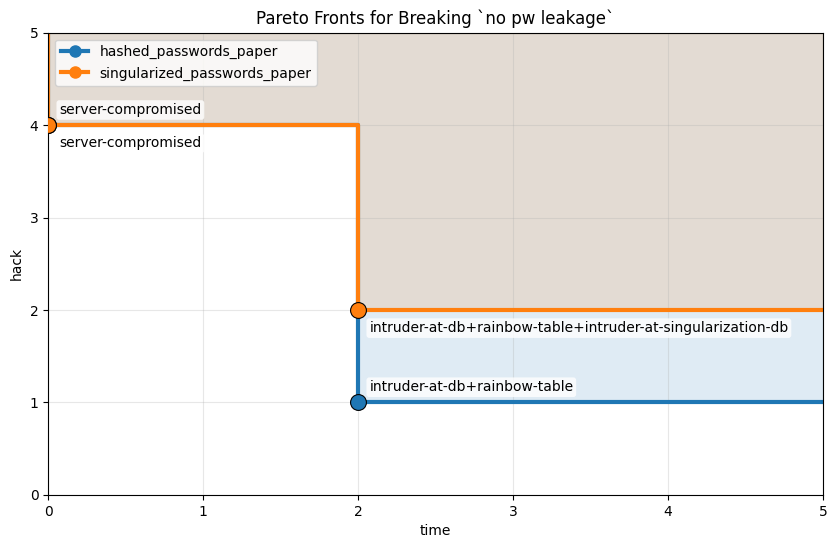

In [15]:
import matplotlib.pyplot as plt

from proverifbatch.scenarios import ParetoFrontRenderer

pareto = ParetoFrontRenderer.from_analysis(
    analysis,
    scenario_aliases={
        "database_leak": "intruder-at-db",
        "rainbow_table_attack": "rainbow-table",
        "singularization_database-leak": "intruder-at-singularization-db",
    },
)

fig, ax = pareto.plot_query(
    TARGET_QUERY_TAG,
    costs=("time", "hack"),
    axis_limits=((0, 5), (0, 5)),
    title="Pareto Fronts for Breaking `no pw leakage`",
    annotation_offsets={
        "hashed_passwords": (8, 8),
        "singularized_passwords": (8, -16),
    },
)
ax.set_xticks([0, 1, 2, 3, 4, 5])
ax.set_yticks([0, 1, 2, 3, 4, 5])
plt.show()

## Attack Trees for `no pw leakage`

The interesting scenarios of baseline and singularized protocol are the cheapest ones where there `no pw leakage` query fails. Our scripts can render trees for the attacks that ProVerif finds, and extract which capabilities are used:

### hashed_passwords_paper — rainbow_table_attack+database_leak.pv

- Minimal combo: `Database leak, Rainbow table attack`  
- Costs: `{'time': 2, 'hack': 1}`

- Scenario capabilities: `Database leak, Rainbow table attack`

Capability nodes shown: 2


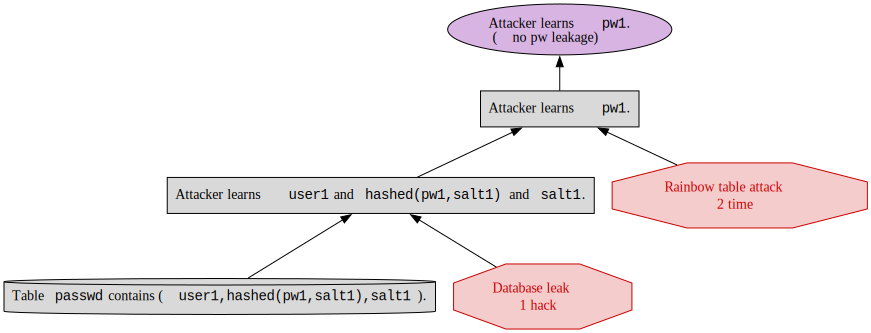

### singularized_passwords_paper — rainbow_table_attack+database_leak+singularization_database_leak.pv

- Minimal combo: `Database leak, Rainbow table attack, Singularization database leak`  
- Costs: `{'time': 2, 'hack': 2}`

- Scenario capabilities: `Database leak, Rainbow table attack, Singularization database leak`

Capability nodes shown: 2


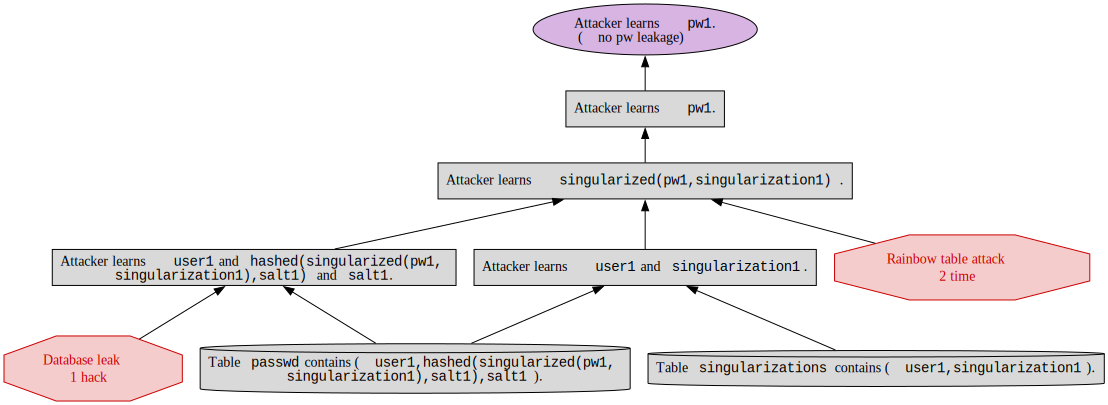

In [16]:

from proverifbatch.attack_tree import AttackTreeExtractor
atk = AttackTreeExtractor(timeout=300)

# Render the pinned scenarios for the no pw leakage query using capability-enhanced trees.
PINNED_SCENARIOS = {
    str(EXAMPLES[0]): "rainbow_table_attack+database_leak.pv",
    str(EXAMPLES[1]): "rainbow_table_attack+database_leak+singularization_database_leak.pv",
}

for input_file in map(str, EXAMPLES):
    scenario = file_to_generated_by_name[input_file][PINNED_SCENARIOS[input_file]]
    model = Path(input_file).stem
    combo_scenarios = sorted(capability.name for capability in scenario.capabilities)

    display(Markdown(f"### {model} — {scenario.path.name}"))
    display(Markdown(f"- Minimal combo: `{', '.join(combo_scenarios) or 'base'}`  \n- Costs: `{scenario.costs}`"))
    display(Markdown(f"- Scenario capabilities: `{', '.join(combo_scenarios) or 'base'}`"))

    build = atk.extract_tree(
        scenario.path,
        query_tag=TARGET_QUERY_TAG,
        scenario_queries=scenario.queries,
        capability_scenarios=file_to_generated[input_file],
        readable_nodes=True,
        show_clause_ids=False,
    )
    if build.tree is None:
        raise RuntimeError("Could not build capability-enhanced tree.")

    capability_node_count = sum(
        1 for node in build.tree.nodes.values() if node.node_type == "capability"
    )
    if capability_node_count == 0:
        print("No capability-specific clauses could be attributed inside this derivation tree.")
    else:
        print(f"Capability nodes shown: {capability_node_count}")

    dot = build.tree.to_graphviz()
    try:
        import graphviz
        src = graphviz.Source(dot, format="svg")
        svg = src.pipe(format="svg").decode("utf-8")
        display(SVG(svg))
    except Exception:
        # Inline SVG rendering unavailable. Showing DOT snippet:"
        print("\n".join(dot.splitlines()[:20]))